import bibliotek


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

pd.set_option('display.max_columns', None)


wczytanie danych i ich odczyt przed modyfikacja

In [16]:
df = pd.read_csv('Global_Superstore2.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Postal Code,Market,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32297,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,United States,10024.0,US,East,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick sssxx,Consumer,New York City,New York,United States,10024.0,US,East,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
2,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,NaN,APAC,Oceania,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
3,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,Australia,NaN,APAC,Oceania,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
4,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,Germany,NaN,EU,Central,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium


Sprawdzenie ile jest pustych wierszy i ich usuniecie

In [17]:
df.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [18]:
df = df.dropna()

wyswietlenie statystyk

In [19]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,9995.000000,9995.000000,9995.000000,9995.000000,9995.000000,9995.000000,9995.000000
mean,36293.100150,55185.860530,230.066084,3.789895,0.156187,28.730286,23.922697
std,2885.296215,32065.271927,623.561030,2.225230,0.206448,234.363265,59.657970
min,31297.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.010000
25%,33794.500000,23223.000000,17.280000,2.000000,0.000000,1.729500,1.490000
50%,36293.000000,56301.000000,54.500000,3.000000,0.200000,8.671000,5.100000
75%,38791.500000,90008.000000,209.955000,5.000000,0.200000,29.364000,19.995000
max,41290.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000,933.570000


Wyswietlenie wszystkich kategorii w datasetcie

In [20]:
unique_cats = df['Category'].value_counts()
unique_cats.head()

Category
Office Supplies    6026
Furniture          2121
Technology         1848
Name: count, dtype: int64

Wyswietlenie ilosc zamowien w regionie

In [21]:
region_order_count = df['Region'].value_counts()
region_order_count.head()

Region
West       3203
East       2849
Central    2323
South      1620
Name: count, dtype: int64

Przygotowanie danych liczbowych do korelacji, usuniecia niepotrzebnych kolumn oraz wyswietlenie przykladowych wierszy

In [22]:
nums_only = df.select_dtypes(include=[np.number])
nums_only = nums_only.drop(columns=['Row ID', 'Postal Code'])
nums_only.head()

,Sales,Quantity,Discount,Profit,Shipping Cost
0,2309.650,7,0.0,762.1845,933.57
1,2309.650,7,0.0,762.1845,933.57
9,5083.960,5,0.2,1906.4850,867.69
10,4297.644,13,0.4,-1862.3124,865.74
11,4164.050,5,0.0,83.2810,846.54


Wyswietlenie korelacji

<Axes: >

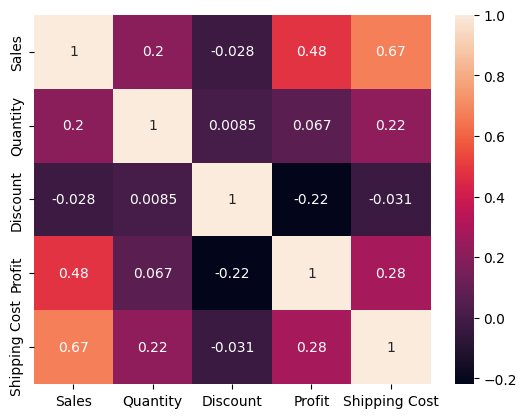

In [23]:
nums_only_corr = nums_only.corr()
sns.heatmap(nums_only_corr, annot=True)

Porownanie sprzedazy vs profitu

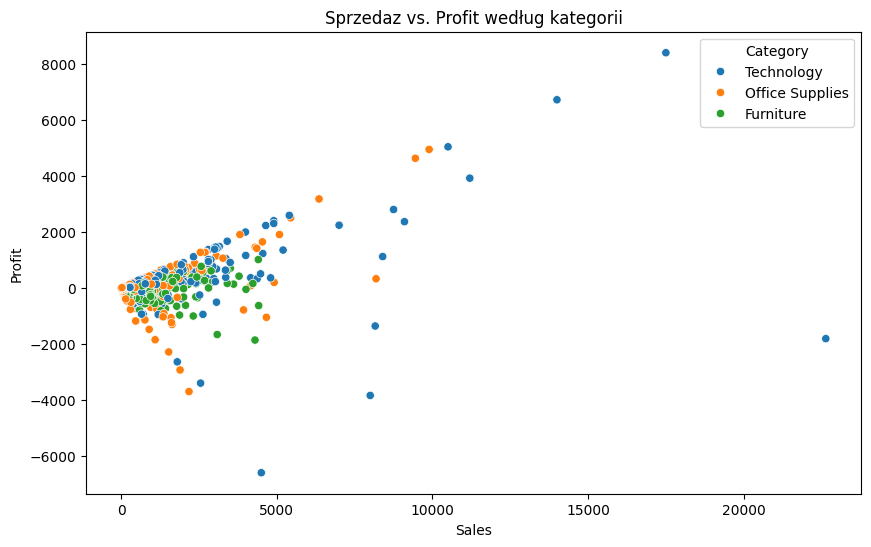

In [24]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category')
plt.title('Sprzedaz vs. Profit według kategorii')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.show()

Srednia dla sprzedazy i profitu

In [25]:
df.groupby('Category')[['Sales', 'Profit']].mean()

,Sales,Profit
Category,,
Furniture,349.834887,8.699327
Office Supplies,119.324101,20.327050
Technology,453.714114,79.121825


**TEST uzywanie cf do rekomendacji

In [26]:
from sklearn.metrics.pairwise import cosine_similarity
user_item_matrix = df.pivot_table(index='Customer Name', columns='Product Name', values='Sales').fillna(0)
# print("Macierz użytkownik-produkty:\n", user_item_matrix)

# Liczymy podobieństwo między użytkownikami
user_similarity = cosine_similarity(user_item_matrix)
user_similarity_df = pd.DataFrame(user_similarity, index=user_item_matrix.index, columns=user_item_matrix.index)
# print("\nPodobieństwo użytkowników:\n", user_similarity_df)

def recommend_products(user, matrix, similarity_df, top_n=1):
    similar_users = similarity_df[user].sort_values(ascending=False).drop(user)
    recommendations = pd.Series(dtype=float)
    
    for sim_user, sim_score in similar_users.items():
        # Produkty, których user jeszcze nie kupił
        products_to_recommend = matrix.loc[sim_user][matrix.loc[user]==0] * sim_score
        # Używamy concat zamiast append
        recommendations = pd.concat([recommendations, products_to_recommend])
    
    # Sumujemy wartości dla tych samych produktów
    recommendations = recommendations.groupby(recommendations.index).sum()
    return recommendations.sort_values(ascending=False).head(top_n)

# Przykład: rekomendacje dla Rick Hansen
client_name = "Rick Hansen"
client_name = "Rick sssxx"


clients = df['Customer Name'].unique()


if client_name not in clients:
    print('user not in db')
else:
    recs = recommend_products(client_name, user_item_matrix, user_similarity_df, top_n=2)
    prev_purchases = df[df['Customer Name'] == client_name]['Product Name'].reset_index(drop=True)
    print(f"\nRekomendacje dla {client_name}:\n\n", recs, f'\n\n\n\nPoprzednie zakupy\n: {prev_purchases}\n\nIle razy sie pojawil w bazie user: {len(prev_purchases)}')
    


Rekomendacje dla Rick sssxx:

 Hon Rectangular Conference Tables          1427.968169
Bevis Round Bullnose 29" High Table Top     985.423003
dtype: float64 



Poprzednie zakupy
: 0    Plantronics CS510 - Over-the-Head monaural Wir...
Name: Product Name, dtype: object

Ile razy sie pojawil w bazie user: 1


In [27]:
products = df['Product ID'].unique()
yoyo = df[['Product ID', 'Product Name',"Category", 'Sub-Category']].drop_duplicates().values.tolist()

for prod in products:
    data = df[df['Product ID'] == prod]
    # yoyo.append((data['Product ID'], data['Product Name']))

print(yoyo)
yoyo_df = pd.DataFrame(yoyo, columns=["Product ID", "Product Name", "Category", 'Sub-Category'])
yoyo_df.to_csv("products_catalog.csv", index=False, encoding="utf-8")

# pd.DataFrame({'Product Name': products, 'Product ID':products_id}).to_csv('xx.csv', index=False)

[['TEC-AC-10003033', 'Plantronics CS510 - Over-the-Head monaural Wireless Headset System', 'Technology', 'Accessories'], ['OFF-BI-10003527', 'Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind', 'Office Supplies', 'Binders'], ['FUR-TA-10000198', 'Chromcraft Bull-Nose Wood Oval Conference Tables & Bases', 'Furniture', 'Tables'], ['OFF-SU-10002881', 'Martin Yale Chadless Opener Electric Letter Opener', 'Office Supplies', 'Supplies'], ['TEC-AC-10004145', 'Logitech diNovo Edge Keyboard', 'Technology', 'Accessories'], ['TEC-PH-10001363', 'Apple iPhone 5S', 'Technology', 'Phones'], ['TEC-PH-10002885', 'Apple iPhone 5', 'Technology', 'Phones'], ['FUR-CH-10002024', 'HON 5400 Series Task Chairs for Big and Tall', 'Furniture', 'Chairs'], ['FUR-TA-10003473', 'Bretford Rectangular Conference Table Tops', 'Furniture', 'Tables'], ['TEC-MA-10003979', 'Ativa V4110MDD Micro-Cut Shredder', 'Technology', 'Machines'], ['TEC-MA-10004125', 'Cubify CubeX 3D Printer Triple Head Print'